Cargando archivos .bin...
Total de audios cargados: 3040
Calculando t-SNE... esto puede tomar unos segundos.


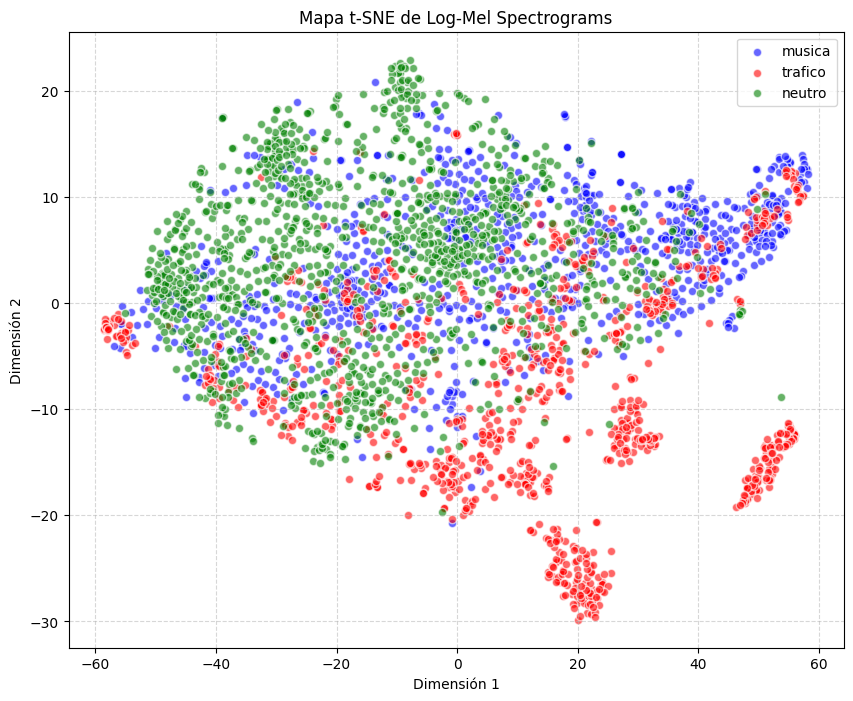

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Configuración de la arquitectura de datos
N_MFCC = 26
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MFCC * N_FRAMES

# 2. Rutas y Clases
BASE_PATH = "./dataset" # Asegúrate de que el notebook esté junto a la carpeta dataset
CLASSES = ["musica", "trafico", "neutro"]
COLORS = ["blue", "red", "green"]

X = []
y = []
file_names = []

print("Cargando archivos .bin...")

# 3. Leer y aplanar los datos
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if not os.path.exists(folder_path):
        print(f"Carpeta no encontrada: {folder_path}")
        continue
        
    for file in os.listdir(folder_path):
        if file.endswith(".bin"):
            file_path = os.path.join(folder_path, file)
            
            # Leer el archivo binario. dtype=np.float32 coincide con el float de C++
            data = np.fromfile(file_path, dtype=np.float32)
            
            # Validar integridad del archivo
            if len(data) == DATAPOINTS_PER_FILE:
                X.append(data) # np.fromfile ya entrega un vector 1D aplanado
                y.append(class_idx)
                file_names.append(file_path)

X = np.array(X)
y = np.array(y)

print(f"Total de audios cargados: {len(X)}")
print("Calculando t-SNE... esto puede tomar unos segundos.")

# 4. Aplicar t-SNE (Reducción a 2 Dimensiones)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X)

# 5. Graficar los resultados
plt.figure(figsize=(10, 8))
for class_idx, class_name in enumerate(CLASSES):
    idx = (y == class_idx)
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], c=COLORS[class_idx], label=class_name, alpha=0.6, edgecolors='w')

plt.title("Mapa t-SNE de Log-Mel Spectrograms")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [1]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# 1. Configuración de tu arquitectura
N_MFCC = 26
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MFCC * N_FRAMES

BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X = []
y = []
file_names = []

print("Cargando archivos .bin...")

# 2. Leer los datos
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    X.append(data)
                    y.append(class_idx)
                    # Guardamos el nombre del archivo con su clase para identificarlo fácil
                    file_names.append(f"[{class_name}] {file}")

X = np.array(X)
y = np.array(y)

print(f"Total de audios cargados: {len(X)}")
print("Calculando t-SNE... esto puede tomar unos segundos.")

# 3. Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X)

# 4. Crear un DataFrame (tabla) para Plotly
df = pd.DataFrame({
    'Eje X': X_2d[:, 0],
    'Eje Y': X_2d[:, 1],
    'Clase': [CLASSES[i] for i in y],
    'Archivo': file_names
})

# 5. Generar el gráfico interactivo
fig = px.scatter(df, x='Eje X', y='Eje Y', color='Clase', hover_name='Archivo',
                 title="Mapa Interactivo de Espectrogramas (Pasa el cursor sobre los puntos)")

# Ajustar el tamaño para que se vea bien en pantalla
fig.update_layout(width=900, height=700)
fig.show()

Cargando archivos .bin...
Total de audios cargados: 3040
Calculando t-SNE... esto puede tomar unos segundos.


In [3]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA # ¡Nueva librería agregada!

# 1. Configuración
N_MFCC = 26
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MFCC * N_FRAMES

BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X = []
y = []
file_names = []

print("Cargando archivos .bin...")

# 2. Leer los datos
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    X.append(data)
                    y.append(class_idx)
                    file_names.append(f"[{class_name}] {file}")

X = np.array(X)
y = np.array(y)

print(f"Total de audios cargados: {len(X)}")

# 3. El truco de optimización: PCA primero
print("Comprimiendo dimensiones con PCA...")
pca = PCA(n_components=50) # Reducimos de 7826 a 50 dimensiones súper rápido
X_pca = pca.fit_transform(X)

# 4. Aplicar t-SNE sobre los datos ya comprimidos
print("Calculando t-SNE... ahora sí será rápido.")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_pca)

# 5. Generar el gráfico interactivo
df = pd.DataFrame({
    'Eje X': X_2d[:, 0],
    'Eje Y': X_2d[:, 1],
    'Clase': [CLASSES[i] for i in y],
    'Archivo': file_names
})

fig = px.scatter(df, x='Eje X', y='Eje Y', color='Clase', hover_name='Archivo',
                 title="Mapa Interactivo de Espectrogramas (PCA + t-SNE)")

fig.update_layout(width=900, height=700)
fig.show(renderer="browser")
print("¡Gráfico generado!")

Cargando archivos .bin...
Total de audios cargados: 3040
Comprimiendo dimensiones con PCA...
Calculando t-SNE... ahora sí será rápido.
¡Gráfico generado!


In [5]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Configuración de dimensiones
N_MFCC = 26
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MFCC * N_FRAMES
BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X_all = []
y_all = []
file_names_all = []

print("Cargando y formateando datos...")

# 2. Cargar TODOS los datos
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    data_2d = data.reshape(N_FRAMES, N_MFCC, 1)
                    X_all.append(data_2d)
                    y_all.append(class_idx)
                    file_names_all.append(f"[{class_name}] {file}")

X_all = np.array(X_all)
y_all = np.array(y_all)

# 3. BALANCEO DEL DATASET (Undersampling)
print("\n--- Balanceando las clases para el entrenamiento ---")
conteo_clases = np.bincount(y_all)
min_muestras = np.min(conteo_clases)

for idx, nombre in enumerate(CLASSES):
    print(f"{nombre}: {conteo_clases[idx]} audios")

print(f"-> Entrenando el modelo con {min_muestras} audios por clase para evitar sesgos.")

indices_balanceados = []
for class_idx in range(len(CLASSES)):
    # Encontrar todos los índices de esta clase
    indices_clase = np.where(y_all == class_idx)[0]
    # Elegir aleatoriamente el número mínimo de muestras
    indices_seleccionados = np.random.choice(indices_clase, min_muestras, replace=False)
    indices_balanceados.extend(indices_seleccionados)

# Desordenar los datos de entrenamiento
np.random.shuffle(indices_balanceados)

X_train = X_all[indices_balanceados]
y_train = y_all[indices_balanceados]

# 4. Construir la CNN
print("\nConstruyendo el modelo...")
model = models.Sequential([
    layers.Input(shape=(N_FRAMES, N_MFCC, 1)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Entrenar con el set BALANCEADO
print("Entrenando el modelo imparcial por 10 épocas...")
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# 6. Buscar intrusos en TODO el dataset
print("\nBuscando audios sospechosos en la totalidad de los datos...")
predicciones = model.predict(X_all)

sospechosos = []

for i in range(len(X_all)):
    clase_real = y_all[i]
    clase_predicha = np.argmax(predicciones[i])
    
    if clase_real != clase_predicha:
        confianza_error = predicciones[i][clase_predicha] * 100
        
        # Filtro de seguridad alta (>75%)
        if confianza_error > 75.0:
            sospechosos.append({
                'Archivo': file_names_all[i],
                'Etiqueta Original': CLASSES[clase_real],
                'Predicción del Modelo': CLASSES[clase_predicha],
                'Confianza del Error (%)': round(confianza_error, 2)
            })

# 7. Mostrar la lista negra
df_errores = pd.DataFrame(sospechosos)

if not df_errores.empty:
    df_errores = df_errores.sort_values(by='Confianza del Error (%)', ascending=False).reset_index(drop=True)
    print(f"\n⚠️ Se encontraron {len(df_errores)} audios altamente sospechosos.")
    display(df_errores.head(50))
else:
    print("\n✅ No se encontraron errores graves. Tu dataset parece estar bastante limpio.")

Cargando y formateando datos...

--- Balanceando las clases para el entrenamiento ---
musica: 800 audios
trafico: 1000 audios
neutro: 1240 audios
-> Entrenando el modelo con 800 audios por clase para evitar sesgos.

Construyendo el modelo...
Entrenando el modelo imparcial por 10 épocas...
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3451 - loss: 1.9194
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3973 - loss: 1.0735
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.3753 - loss: 1.0868
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4522 - loss: 1.0714
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5029 - loss: 0.9600
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5748 - loss: 0.8609
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6445 - loss: 0.7629
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6684 - loss: 0.7367
Epoch 9/10
75/75 ━━━━━━━━━━━━━

,Archivo,Etiqueta Original,Predicción del Modelo,Confianza del Error (%)
0,[neutro] neutro_S3_079.bin,neutro,musica,93.349998
1,[musica] musica_S15_002.bin,musica,neutro,92.839996
2,[neutro] 1 (10).bin,neutro,trafico,92.839996
3,[neutro] 1 (2).bin,neutro,trafico,92.650002
4,[neutro] neutro_S3_128.bin,neutro,musica,90.199997
5,[trafico] trafico_S14_002.bin,trafico,neutro,89.800003
6,[musica] musica_S13_003.bin,musica,neutro,89.709999
7,[musica] musica_S4_001.bin,musica,neutro,88.269997
8,[musica] musica_S15_004.bin,musica,neutro,87.919998
9,[trafico] trafico_S14_004.bin,trafico,neutro,87.769997


In [7]:
import os
import shutil
import IPython.display as ipd
from IPython.display import clear_output

# Verificamos si la variable df_errores existe del script anterior
if 'df_errores' not in globals() or df_errores.empty:
    print("❌ No hay audios sospechosos en memoria. Ejecuta el script de entrenamiento primero.")
else:
    print(f"🔍 Iniciando revisión de {len(df_errores)} audios sospechosos...\n")
    
    contador_borrados = 0
    contador_movidos = 0
    
    for index, row in df_errores.iterrows():
        clear_output(wait=True)
        
        etiqueta_original = row['Etiqueta Original']
        prediccion_modelo = row['Predicción del Modelo']
        confianza = row['Confianza del Error (%)']
        archivo_completo = row['Archivo']
        
        # Extraemos los nombres de archivo
        nombre_bin = archivo_completo.split("] ")[1]
        nombre_wav = nombre_bin.replace(".bin", ".wav")
        
        # Rutas de origen (donde están ahora)
        ruta_bin_origen = os.path.join(BASE_PATH, etiqueta_original, "mel", nombre_bin)
        ruta_wav_origen = os.path.join(BASE_PATH, etiqueta_original, "wav", nombre_wav)
        
        # Rutas de destino (a donde el modelo sugiere moverlos)
        ruta_bin_destino = os.path.join(BASE_PATH, prediccion_modelo, "mel", nombre_bin)
        ruta_wav_destino = os.path.join(BASE_PATH, prediccion_modelo, "wav", nombre_wav)
        
        print("=" * 70)
        print(f"🎧 AUDIO {index + 1} de {len(df_errores)}")
        print(f"📊 Estadísticas -> Eliminados: {contador_borrados} | Reubicados: {contador_movidos}")
        print("-" * 70)
        print(f"📁 Carpeta actual (Tu etiqueta): {etiqueta_original.upper()}")
        print(f"🤖 El modelo sugiere mover a:   {prediccion_modelo.upper()} (Seguridad: {confianza}%)")
        print("=" * 70)
        
        if os.path.exists(ruta_wav_origen):
            display(ipd.Audio(ruta_wav_origen))
            
            print("\nOpciones:")
            print("[b] = Borrar archivo (elimina .wav y .bin permanentemente)")
            print(f"[c] = Cambiar clase (mover archivos a la carpeta '{prediccion_modelo.upper()}')")
            print("[m] = Mantener (la etiqueta original era correcta)")
            print("[s] = Salir de la revisión")
            
            decision = input("👉 Ingresa tu decisión (b/c/m/s) y presiona Enter: ").strip().lower()
            
            if decision == 's':
                print("\n🛑 Revisión detenida por el usuario.")
                break
                
            elif decision == 'b':
                try:
                    if os.path.exists(ruta_bin_origen): os.remove(ruta_bin_origen)
                    if os.path.exists(ruta_wav_origen): os.remove(ruta_wav_origen)
                    contador_borrados += 1
                    print("🗑️ Archivos eliminados exitosamente.")
                except Exception as e:
                    print(f"❌ Error al eliminar: {e}")
                    
            elif decision == 'c':
                try:
                    if os.path.exists(ruta_bin_origen): shutil.move(ruta_bin_origen, ruta_bin_destino)
                    if os.path.exists(ruta_wav_origen): shutil.move(ruta_wav_origen, ruta_wav_destino)
                    contador_movidos += 1
                    print(f"🚚 Archivos movidos exitosamente a {prediccion_modelo.upper()}.")
                except Exception as e:
                    print(f"❌ Error al mover los archivos: {e}")
                    
            elif decision == 'm':
                print("✅ Archivo mantenido en su carpeta original.")
            else:
                print("⚠️ Opción no válida. Se mantendrá el archivo por seguridad.")
        else:
            print(f"❌ No se encontró el audio: {ruta_wav_origen}")
            input("Presiona Enter para continuar...")

    clear_output(wait=True)
    print("✨ REVISIÓN FINALIZADA ✨")
    print(f"Total de intrusos eliminados: {contador_borrados}")
    print(f"Total de audios reubicados: {contador_movidos}")

✨ REVISIÓN FINALIZADA ✨
Total de intrusos eliminados: 24
Total de audios reubicados: 5


Cargando el dataset limpio...

Balanceando a 791 muestras por clase...
Datos de Entrenamiento: 1898 | Datos de Prueba (Invisibles para la red): 475

Iniciando entrenamiento formal (20 épocas)...
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3599 - loss: 3.1158 - val_accuracy: 0.3347 - val_loss: 1.0986
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3436 - loss: 1.0985 - val_accuracy: 0.3347 - val_loss: 1.0986
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.3464 - loss: 1.0983 - val_accuracy: 0.3432 - val_loss: 1.0986
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.3116 - loss: 1.0986 - val_accuracy: 0.3347 - val_loss: 1.0986
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.3141 - loss: 1.0994 - val_accuracy: 0.3347 - val_loss: 1.0986
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3419 - loss: 1.0982 - val_accuracy: 0.3347 - val_loss: 1.0987
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28

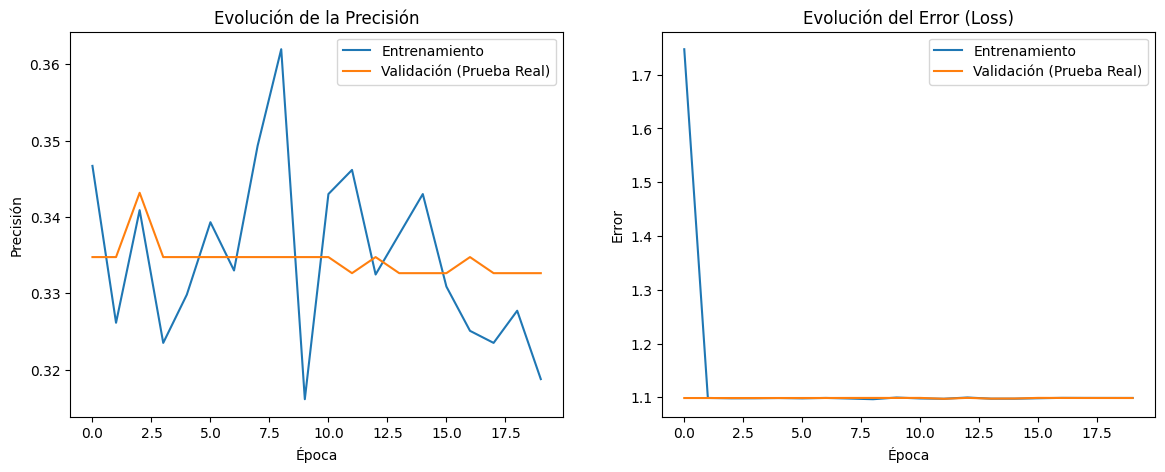

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      musica       0.00      0.00      0.00       158
     trafico       0.33      1.00      0.50       158
      neutro       0.00      0.00      0.00       159

    accuracy                           0.33       475
   macro avg       0.11      0.33      0.17       475
weighted avg       0.11      0.33      0.17       475



C:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

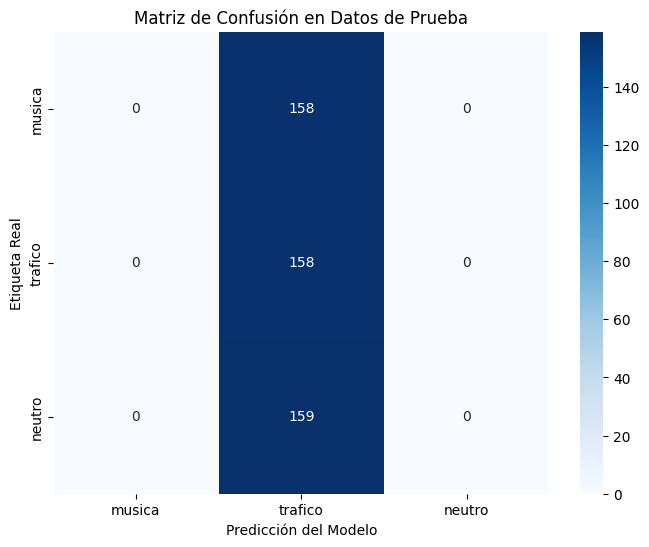


✅ Modelo guardado como 'modelo_clasificacion_audio.h5'


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Configuración inicial
N_MFCC = 26
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MFCC * N_FRAMES
BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X_all, y_all = [], []

print("Cargando el dataset limpio...")

# 2. Cargar los datos
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    data_2d = data.reshape(N_FRAMES, N_MFCC, 1)
                    X_all.append(data_2d)
                    y_all.append(class_idx)

X_all = np.array(X_all)
y_all = np.array(y_all)

# 3. Balanceo de clases (Undersampling sobre los datos ya limpios)
conteo = np.bincount(y_all)
min_muestras = np.min(conteo)
print(f"\nBalanceando a {min_muestras} muestras por clase...")

indices_balanceados = []
for i in range(len(CLASSES)):
    idx_clase = np.where(y_all == i)[0]
    idx_seleccionados = np.random.choice(idx_clase, min_muestras, replace=False)
    indices_balanceados.extend(idx_seleccionados)

np.random.shuffle(indices_balanceados)
X_bal = X_all[indices_balanceados]
y_bal = y_all[indices_balanceados]

# 4. Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)
print(f"Datos de Entrenamiento: {len(X_train)} | Datos de Prueba (Invisibles para la red): {len(X_test)}")

# 5. Arquitectura del Modelo Definitivo (con Dropout para evitar Overfitting)
model = models.Sequential([
    layers.Input(shape=(N_FRAMES, N_MFCC, 1)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Apaga el 25% de las neuronas temporalmente
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Entrenamiento (Guardando la historia para graficar)
print("\nIniciando entrenamiento formal (20 épocas)...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# 7. Evaluación y Gráficos
print("\nGenerando métricas y gráficos...")

# 7.1 Gráficas de Aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Precisión (Accuracy)
axes[0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación (Prueba Real)')
axes[0].set_title('Evolución de la Precisión')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Precisión')
axes[0].legend()

# Curva de Error (Loss)
axes[1].plot(history.history['loss'], label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación (Prueba Real)')
axes[1].set_title('Evolución del Error (Loss)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Error')
axes[1].legend()

plt.show()

# 7.2 Matriz de Confusión y Reporte
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matriz de Confusión en Datos de Prueba')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# Guardar el modelo en formato Keras (para luego convertirlo a TFLite)
model.save("modelo_clasificacion_audio.h5")
print("\n✅ Modelo guardado como 'modelo_clasificacion_audio.h5'")

Cargando el dataset limpio y formateando la memoria...

Balanceando a 791 muestras por clase para evitar sesgos...
Datos de Entrenamiento: 1898 | Datos de Prueba (Invisibles para la red): 475

Construyendo la Red Neuronal Convolucional...

Iniciando entrenamiento formal (20 épocas)...
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3419 - loss: 5.2921 - val_accuracy: 0.3558 - val_loss: 1.0990
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3369 - loss: 1.0994 - val_accuracy: 0.3347 - val_loss: 1.0986
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3295 - loss: 1.0988 - val_accuracy: 0.3347 - val_loss: 1.0986
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3459 - loss: 1.0986 - val_accuracy: 0.3347 - val_loss: 1.0986
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3369 - loss: 1.0986 - val_accuracy: 0.3347 - val_loss: 1.0986
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3470 - loss: 1

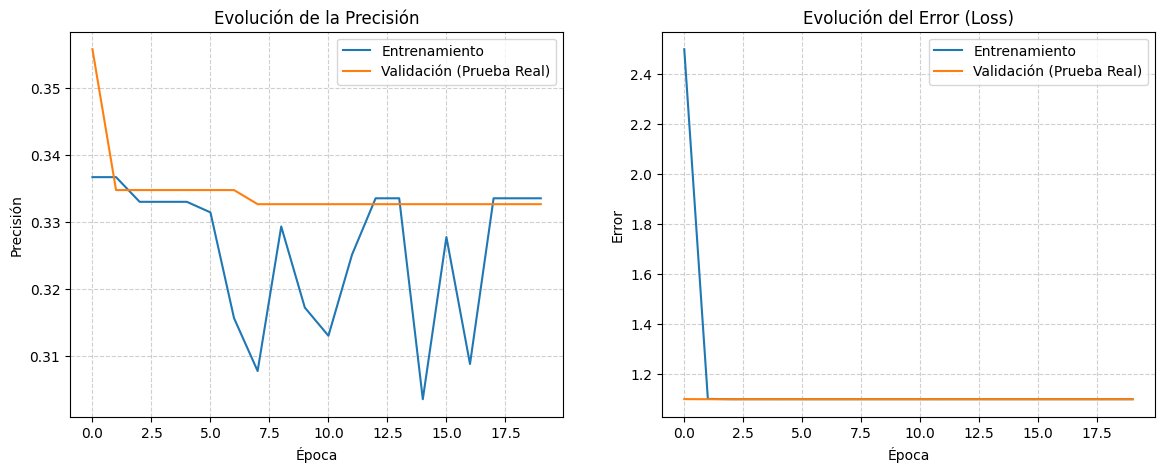

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      musica       0.00      0.00      0.00       158
     trafico       0.33      1.00      0.50       158
      neutro       0.00      0.00      0.00       159

    accuracy                           0.33       475
   macro avg       0.11      0.33      0.17       475
weighted avg       0.11      0.33      0.17       475



C:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

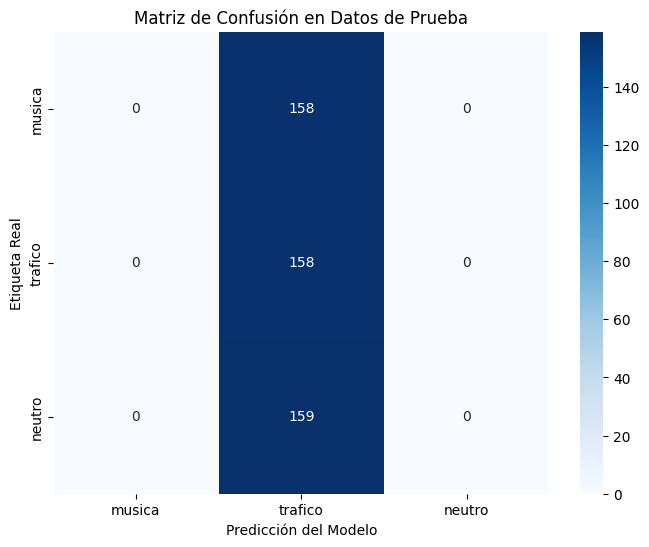


✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. CONFIGURACIÓN INICIAL
# ==========================================
N_MFCC = 26
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MFCC * N_FRAMES
BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X_all, y_all = [], []

print("Cargando el dataset limpio y formateando la memoria...")

# ==========================================
# 2. CARGA DE DATOS Y CORRECCIÓN DE MEMORIA
# ==========================================
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                # Tu ESP32 guardó los datos como float32, leemos en ese mismo formato
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    
                    # 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
                    # 🐛 AQUÍ ESTABA EL ERROR FATAL: LECTURA DE MEMORIA C++ vs PYTHON 🐛
                    # 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
                    
                    # ❌ INCORRECTO (Lo que hacíamos antes, mezclaba tiempo y frecuencia):
                    # data_2d = data.reshape(N_FRAMES, N_MFCC, 1) 
                    
                    # ✅ CORRECTO:
                    # PASO A: Leer exactamente como el array de C++ (float mel[N_MFCC][N_FRAMES]) se guardó en la SD
                    data_correcta = data.reshape(N_MFCC, N_FRAMES)
                    
                    # PASO B: Transponer (girar) la matriz para intercambiar los ejes. 
                    # Ahora el Tiempo (301) está en el eje X y las Frecuencias (26) en el eje Y.
                    data_transpuesta = data_correcta.T
                    
                    # PASO C: Añadir la dimensión de "canal de color" (1) que exige la CNN
                    # Resultado final esperado por la red: (301, 26, 1)
                    data_2d = np.expand_dims(data_transpuesta, axis=-1)
                    
                    # 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
                    
                    X_all.append(data_2d)
                    y_all.append(class_idx)

X_all = np.array(X_all)
y_all = np.array(y_all)

# ==========================================
# 3. BALANCEO DE CLASES (Undersampling)
# ==========================================
conteo = np.bincount(y_all)
min_muestras = np.min(conteo)
print(f"\nBalanceando a {min_muestras} muestras por clase para evitar sesgos...")

indices_balanceados = []
for i in range(len(CLASSES)):
    idx_clase = np.where(y_all == i)[0]
    idx_seleccionados = np.random.choice(idx_clase, min_muestras, replace=False)
    indices_balanceados.extend(idx_seleccionados)

np.random.shuffle(indices_balanceados)
X_bal = X_all[indices_balanceados]
y_bal = y_all[indices_balanceados]

# ==========================================
# 4. DIVISIÓN TRAIN/TEST (80% / 20%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)
print(f"Datos de Entrenamiento: {len(X_train)} | Datos de Prueba (Invisibles para la red): {len(X_test)}")

# ==========================================
# 5. ARQUITECTURA DEL MODELO (Con Dropout)
# ==========================================
print("\nConstruyendo la Red Neuronal Convolucional...")
model = models.Sequential([
    layers.Input(shape=(N_FRAMES, N_MFCC, 1)),
    
    # Primera capa de extracción de características
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Obliga a no memorizar el ruido
    
    # Segunda capa (patrones más complejos)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Toma de decisiones
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Capa de mayor exigencia para generalizar
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
print("\nIniciando entrenamiento formal (20 épocas)...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# ==========================================
# 7. EVALUACIÓN Y GRÁFICOS PARA EL REPORTE
# ==========================================
print("\nGenerando métricas y gráficos...")

# 7.1 Curvas de Aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación (Prueba Real)')
axes[0].set_title('Evolución de la Precisión')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Precisión')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history.history['loss'], label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación (Prueba Real)')
axes[1].set_title('Evolución del Error (Loss)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Error')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.show()

# 7.2 Matriz de Confusión
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matriz de Confusión en Datos de Prueba')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# ==========================================
# 8. GUARDAR EL MODELO
# ==========================================
model.save("modelo_clasificacion_audio.h5")
print("\n✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite")

In [ ]:
Escalando los datos al dividir por 15
20 epocas

Cargando el dataset limpio y formateando la memoria...

Balanceando a 791 muestras por clase para evitar sesgos...

Escalando los datos al rango [0, 1] dividiendo por 15.0...
Datos de Entrenamiento: 1898 | Datos de Prueba (Invisibles para la red): 475

Construyendo la Red Neuronal Convolucional...

Iniciando entrenamiento formal (20 épocas)...
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3355 - loss: 1.1806 - val_accuracy: 0.4905 - val_loss: 1.0953
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3383 - loss: 1.0987 - val_accuracy: 0.3326 - val_loss: 1.0962
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3489 - loss: 1.0954 - val_accuracy: 0.5558 - val_loss: 1.0861
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4204 - loss: 1.0867 - val_accuracy: 0.3495 - val_loss: 1.0936
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4021 - loss: 1.0694 - val_accuracy: 0.4337 - val_loss: 0.9959
Epoch 6/20
60/60 ━━

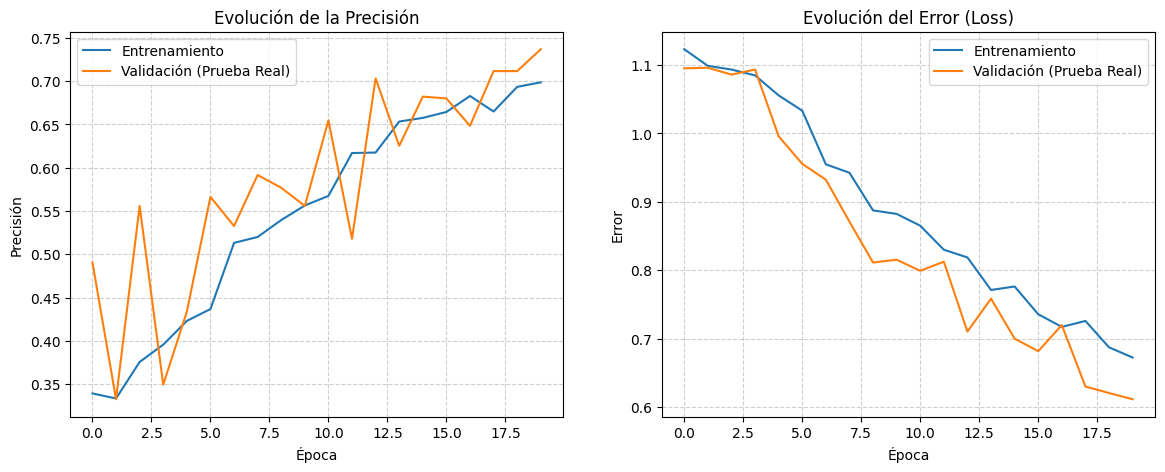

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      musica       0.69      0.58      0.63       158
     trafico       0.83      0.83      0.83       158
      neutro       0.69      0.81      0.74       159

    accuracy                           0.74       475
   macro avg       0.74      0.74      0.73       475
weighted avg       0.74      0.74      0.73       475



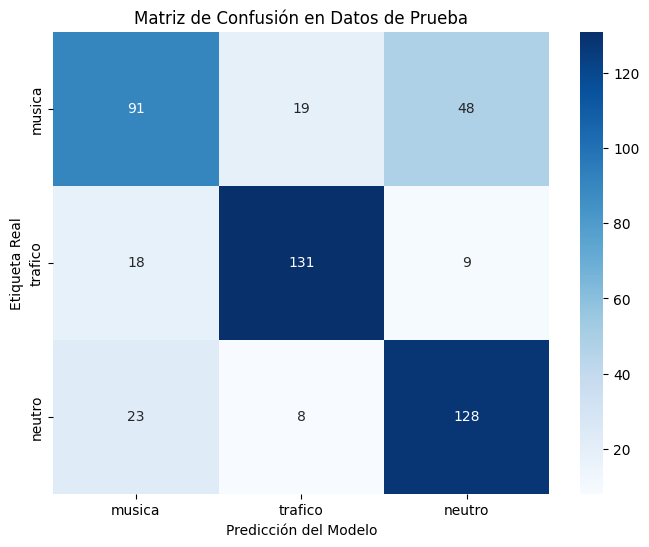


✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. CONFIGURACIÓN INICIAL (CORREGIDA)
# ==========================================
N_MELS = 26   # 🚀 CORRECCIÓN 1: Nomenclatura correcta (Log-Mel, no MFCC)
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MELS * N_FRAMES
BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X_all, y_all = [], []

print("Cargando el dataset limpio y formateando la memoria...")

# ==========================================
# 2. CARGA DE DATOS Y CORRECCIÓN DE MEMORIA
# ==========================================
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    
                    # 🚨 LECTURA DE MEMORIA C++ vs PYTHON CORREGIDA 🚨
                    # PASO A: Leer exactamente como el array de C++ (float mel[N_MELS][N_FRAMES])
                    data_correcta = data.reshape(N_MELS, N_FRAMES)
                    
                    # PASO B: Transponer (girar) la matriz para intercambiar los ejes. 
                    data_transpuesta = data_correcta.T
                    
                    # PASO C: Añadir la dimensión de "canal de color" (1) que exige la CNN
                    data_2d = np.expand_dims(data_transpuesta, axis=-1)
                    
                    X_all.append(data_2d)
                    y_all.append(class_idx)

X_all = np.array(X_all)
y_all = np.array(y_all)

# ==========================================
# 3. BALANCEO DE CLASES (Undersampling)
# ==========================================
conteo = np.bincount(y_all)
min_muestras = np.min(conteo)
print(f"\nBalanceando a {min_muestras} muestras por clase para evitar sesgos...")

indices_balanceados = []
for i in range(len(CLASSES)):
    idx_clase = np.where(y_all == i)[0]
    idx_seleccionados = np.random.choice(idx_clase, min_muestras, replace=False)
    indices_balanceados.extend(idx_seleccionados)

np.random.shuffle(indices_balanceados)
X_bal = X_all[indices_balanceados]
y_bal = y_all[indices_balanceados]

# ==========================================
# 4. DIVISIÓN TRAIN/TEST (80% / 20%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

# ==========================================
# 4.5 ESCALADO SUAVE (0.0 a 1.0)
# ==========================================
print("\nEscalando los datos al rango [0, 1] dividiendo por 15.0...")
# 🚀 CORRECCIÓN 2: Evita el colapso del gradiente (Loss = 5.0+) en la Época 1
X_train = X_train / 15.0
X_test = X_test / 15.0

print(f"Datos de Entrenamiento: {len(X_train)} | Datos de Prueba (Invisibles para la red): {len(X_test)}")

# ==========================================
# 5. ARQUITECTURA DEL MODELO (Sin Dropout)
# ==========================================
print("\nConstruyendo la Red Neuronal Convolucional...")
model = models.Sequential([
    layers.Input(shape=(N_FRAMES, N_MELS, 1)), # Ajustado a la nueva nomenclatura
    
    # Primera capa de extracción de características
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Segunda capa (patrones más complejos)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Toma de decisiones
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    # Capas de Dropout eliminadas para permitir que la red aprenda a toda capacidad
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
print("\nIniciando entrenamiento formal (20 épocas)...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)
##history = model.fit(X_train, y_train, epochs=70, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# ==========================================
# 7. EVALUACIÓN Y GRÁFICOS PARA EL REPORTE
# ==========================================
print("\nGenerando métricas y gráficos...")

# 7.1 Curvas de Aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación (Prueba Real)')
axes[0].set_title('Evolución de la Precisión')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Precisión')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history.history['loss'], label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación (Prueba Real)')
axes[1].set_title('Evolución del Error (Loss)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Error')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.show()

# 7.2 Matriz de Confusión
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matriz de Confusión en Datos de Prueba')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# ==========================================
# 8. GUARDAR EL MODELO
# ==========================================
model.save("modelo_clasificacion_audio.h5")
print("\n✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite")

Cargando el dataset limpio y formateando la memoria...

Balanceando a 791 muestras por clase para evitar sesgos...

Escalando los datos al rango [0, 1] dividiendo por 15.0...
Datos de Entrenamiento: 1898 | Datos de Prueba (Invisibles para la red): 475

Construyendo la Red Neuronal Convolucional...

Iniciando entrenamiento formal (20 épocas)...
Epoch 1/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3437 - loss: 1.1429 - val_accuracy: 0.4232 - val_loss: 1.0966
Epoch 2/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3820 - loss: 1.0969 - val_accuracy: 0.4926 - val_loss: 1.0827
Epoch 3/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3882 - loss: 1.0827 - val_accuracy: 0.3979 - val_loss: 1.0518
Epoch 4/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4710 - loss: 1.0107 - val_accuracy: 0.5621 - val_loss: 0.9421
Epoch 5/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5106 - loss: 0.9539 - val_accuracy: 0.4863 - val_loss: 0.9479
Epoch 6/70
60/60 ━━

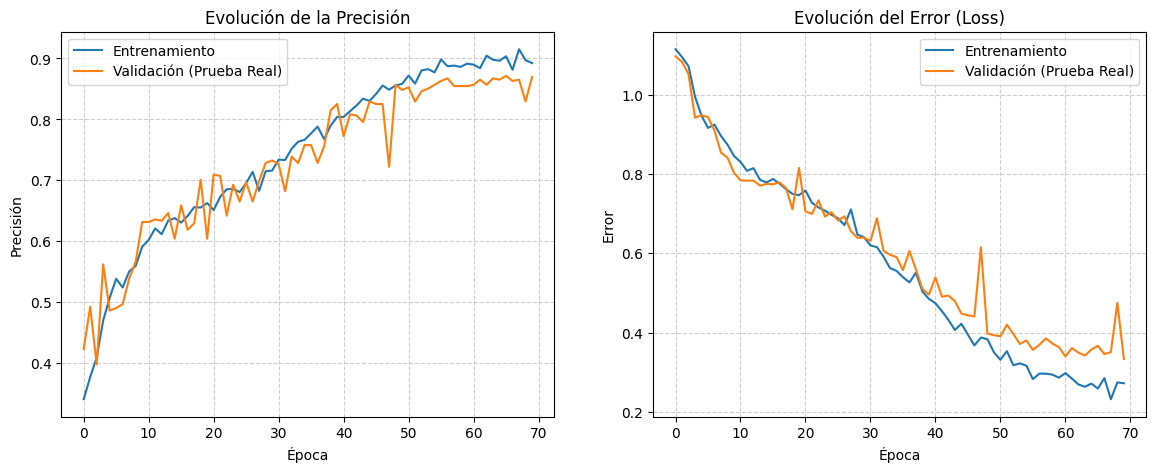

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      musica       0.85      0.80      0.82       158
     trafico       0.90      0.94      0.92       158
      neutro       0.85      0.87      0.86       159

    accuracy                           0.87       475
   macro avg       0.87      0.87      0.87       475
weighted avg       0.87      0.87      0.87       475



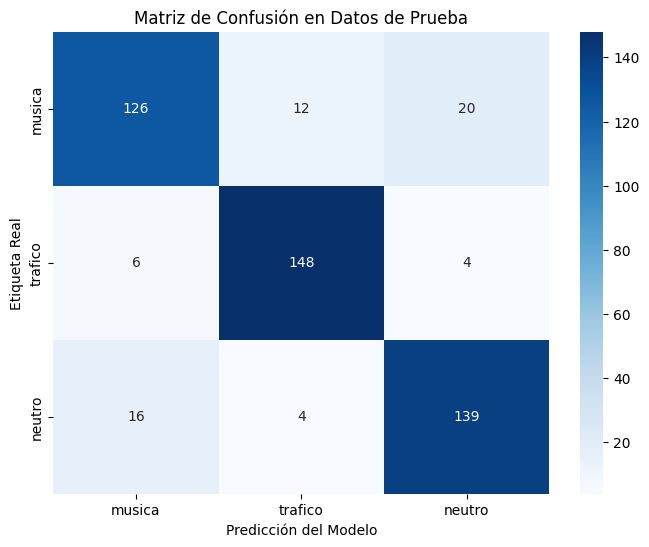


✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. CONFIGURACIÓN INICIAL (CORREGIDA)
# ==========================================
N_MELS = 26   # 🚀 CORRECCIÓN 1: Nomenclatura correcta (Log-Mel, no MFCC)
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MELS * N_FRAMES
BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X_all, y_all = [], []

print("Cargando el dataset limpio y formateando la memoria...")

# ==========================================
# 2. CARGA DE DATOS Y CORRECCIÓN DE MEMORIA
# ==========================================
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    
                    # 🚨 LECTURA DE MEMORIA C++ vs PYTHON CORREGIDA 🚨
                    # PASO A: Leer exactamente como el array de C++ (float mel[N_MELS][N_FRAMES])
                    data_correcta = data.reshape(N_MELS, N_FRAMES)
                    
                    # PASO B: Transponer (girar) la matriz para intercambiar los ejes. 
                    data_transpuesta = data_correcta.T
                    
                    # PASO C: Añadir la dimensión de "canal de color" (1) que exige la CNN
                    data_2d = np.expand_dims(data_transpuesta, axis=-1)
                    
                    X_all.append(data_2d)
                    y_all.append(class_idx)

X_all = np.array(X_all)
y_all = np.array(y_all)

# ==========================================
# 3. BALANCEO DE CLASES (Undersampling)
# ==========================================
conteo = np.bincount(y_all)
min_muestras = np.min(conteo)
print(f"\nBalanceando a {min_muestras} muestras por clase para evitar sesgos...")

indices_balanceados = []
for i in range(len(CLASSES)):
    idx_clase = np.where(y_all == i)[0]
    idx_seleccionados = np.random.choice(idx_clase, min_muestras, replace=False)
    indices_balanceados.extend(idx_seleccionados)

np.random.shuffle(indices_balanceados)
X_bal = X_all[indices_balanceados]
y_bal = y_all[indices_balanceados]

# ==========================================
# 4. DIVISIÓN TRAIN/TEST (80% / 20%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

# ==========================================
# 4.5 ESCALADO SUAVE (0.0 a 1.0)
# ==========================================
print("\nEscalando los datos al rango [0, 1] dividiendo por 15.0...")
# 🚀 CORRECCIÓN 2: Evita el colapso del gradiente (Loss = 5.0+) en la Época 1
X_train = X_train / 15.0
X_test = X_test / 15.0

print(f"Datos de Entrenamiento: {len(X_train)} | Datos de Prueba (Invisibles para la red): {len(X_test)}")

# ==========================================
# 5. ARQUITECTURA DEL MODELO (Sin Dropout)
# ==========================================
print("\nConstruyendo la Red Neuronal Convolucional...")
model = models.Sequential([
    layers.Input(shape=(N_FRAMES, N_MELS, 1)), # Ajustado a la nueva nomenclatura
    
    # Primera capa de extracción de características
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Segunda capa (patrones más complejos)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Toma de decisiones
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    # Capas de Dropout eliminadas para permitir que la red aprenda a toda capacidad
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
print("\nIniciando entrenamiento formal (20 épocas)...")
##history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)
history = model.fit(X_train, y_train, epochs=70, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# ==========================================
# 7. EVALUACIÓN Y GRÁFICOS PARA EL REPORTE
# ==========================================
print("\nGenerando métricas y gráficos...")

# 7.1 Curvas de Aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación (Prueba Real)')
axes[0].set_title('Evolución de la Precisión')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Precisión')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history.history['loss'], label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación (Prueba Real)')
axes[1].set_title('Evolución del Error (Loss)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Error')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.show()

# 7.2 Matriz de Confusión
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matriz de Confusión en Datos de Prueba')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# ==========================================
# 8. GUARDAR EL MODELO
# ==========================================
model.save("modelo_clasificacion_audio.h5")
print("\n✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite")

Con ligero dropout
70 epocas


Cargando el dataset limpio y formateando la memoria...

Balanceando a 791 muestras por clase para evitar sesgos...

Escalando los datos al rango [0, 1] dividiendo por 15.0...
Datos de Entrenamiento: 1898 | Datos de Prueba (Invisibles para la red): 475

Construyendo la CNN con Dropout Quirúrgico...

Iniciando entrenamiento formal (20 épocas)...
Epoch 1/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3328 - loss: 1.1529 - val_accuracy: 0.3895 - val_loss: 1.0974
Epoch 2/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3329 - loss: 1.0962 - val_accuracy: 0.3368 - val_loss: 1.0902
Epoch 3/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3566 - loss: 1.0908 - val_accuracy: 0.3368 - val_loss: 1.0785
Epoch 4/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3902 - loss: 1.0802 - val_accuracy: 0.4021 - val_loss: 1.0519
Epoch 5/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4714 - loss: 1.0334 - val_accuracy: 0.4863 - val_loss: 0.9575
Epoch 6/70
60/60 ━━

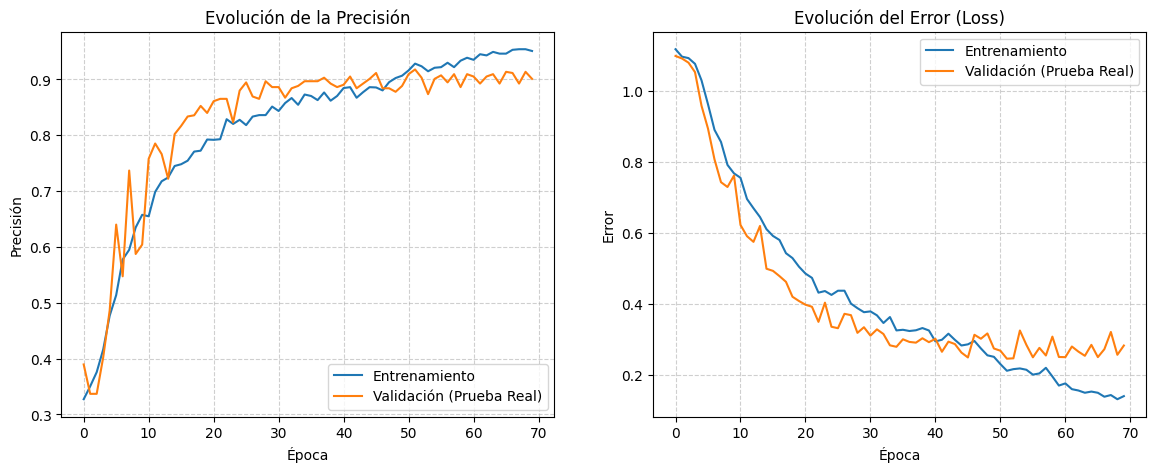

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      musica       0.93      0.78      0.85       158
     trafico       0.92      0.96      0.94       158
      neutro       0.86      0.96      0.91       159

    accuracy                           0.90       475
   macro avg       0.90      0.90      0.90       475
weighted avg       0.90      0.90      0.90       475



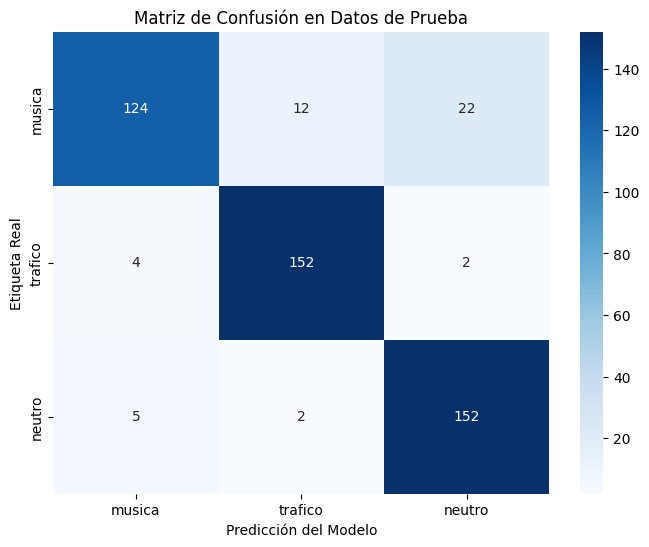


✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. CONFIGURACIÓN INICIAL (CORREGIDA)
# ==========================================
N_MELS = 26   # 🚀 CORRECCIÓN 1: Nomenclatura correcta (Log-Mel, no MFCC)
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MELS * N_FRAMES
BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X_all, y_all = [], []

print("Cargando el dataset limpio y formateando la memoria...")

# ==========================================
# 2. CARGA DE DATOS Y CORRECCIÓN DE MEMORIA
# ==========================================
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    
                    # 🚨 LECTURA DE MEMORIA C++ vs PYTHON CORREGIDA 🚨
                    # PASO A: Leer exactamente como el array de C++ (float mel[N_MELS][N_FRAMES])
                    data_correcta = data.reshape(N_MELS, N_FRAMES)
                    
                    # PASO B: Transponer (girar) la matriz para intercambiar los ejes. 
                    data_transpuesta = data_correcta.T
                    
                    # PASO C: Añadir la dimensión de "canal de color" (1) que exige la CNN
                    data_2d = np.expand_dims(data_transpuesta, axis=-1)
                    
                    X_all.append(data_2d)
                    y_all.append(class_idx)

X_all = np.array(X_all)
y_all = np.array(y_all)

# ==========================================
# 3. BALANCEO DE CLASES (Undersampling)
# ==========================================
conteo = np.bincount(y_all)
min_muestras = np.min(conteo)
print(f"\nBalanceando a {min_muestras} muestras por clase para evitar sesgos...")

indices_balanceados = []
for i in range(len(CLASSES)):
    idx_clase = np.where(y_all == i)[0]
    idx_seleccionados = np.random.choice(idx_clase, min_muestras, replace=False)
    indices_balanceados.extend(idx_seleccionados)

np.random.shuffle(indices_balanceados)
X_bal = X_all[indices_balanceados]
y_bal = y_all[indices_balanceados]

# ==========================================
# 4. DIVISIÓN TRAIN/TEST (80% / 20%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

# ==========================================
# 4.5 ESCALADO SUAVE (0.0 a 1.0)
# ==========================================
print("\nEscalando los datos al rango [0, 1] dividiendo por 15.0...")
# 🚀 CORRECCIÓN 2: Evita el colapso del gradiente (Loss = 5.0+) en la Época 1
X_train = X_train / 15.0
X_test = X_test / 15.0

print(f"Datos de Entrenamiento: {len(X_train)} | Datos de Prueba (Invisibles para la red): {len(X_test)}")

# ==========================================
# 5. ARQUITECTURA DEL MODELO (Con Dropout Ligero)
# ==========================================
print("\nConstruyendo la CNN con Dropout Quirúrgico...")
model = models.Sequential([
    layers.Input(shape=(N_FRAMES, N_MELS, 1)), 
    
    # Capas de extracción al 100% de capacidad
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Toma de decisiones
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    
    # 🚀 Aquí agregamos el Dropout Ligero (apagamos solo el 15% de las neuronas)
    layers.Dropout(0.15), 
    
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
print("\nIniciando entrenamiento formal (20 épocas)...")
##history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)
history = model.fit(X_train, y_train, epochs=70, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# ==========================================
# 7. EVALUACIÓN Y GRÁFICOS PARA EL REPORTE
# ==========================================
print("\nGenerando métricas y gráficos...")

# 7.1 Curvas de Aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación (Prueba Real)')
axes[0].set_title('Evolución de la Precisión')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Precisión')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history.history['loss'], label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación (Prueba Real)')
axes[1].set_title('Evolución del Error (Loss)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Error')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.show()

# 7.2 Matriz de Confusión
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matriz de Confusión en Datos de Prueba')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# ==========================================
# 8. GUARDAR EL MODELO
# ==========================================
model.save("modelo_clasificacion_audio.h5")
print("\n✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite")

Cargando el dataset limpio y formateando la memoria...

Balanceando a 791 muestras por clase para evitar sesgos...

Escalando los datos al rango [0, 1] dividiendo por 15.0...
Datos de Entrenamiento: 1898 | Datos de Prueba (Invisibles para la red): 475

Construyendo la CNN con Dropout Quirúrgico...

Iniciando entrenamiento formal (20 épocas)...
Epoch 1/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3335 - loss: 1.1373 - val_accuracy: 0.3853 - val_loss: 1.0972
Epoch 2/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3533 - loss: 1.1001 - val_accuracy: 0.6042 - val_loss: 1.0879
Epoch 3/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3875 - loss: 1.0880 - val_accuracy: 0.3642 - val_loss: 1.0730
Epoch 4/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4352 - loss: 1.0717 - val_accuracy: 0.5200 - val_loss: 1.0305
Epoch 5/70
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4801 - loss: 1.0344 - val_accuracy: 0.6884 - val_loss: 0.9508
Epoch 6/70
60/60 ━━

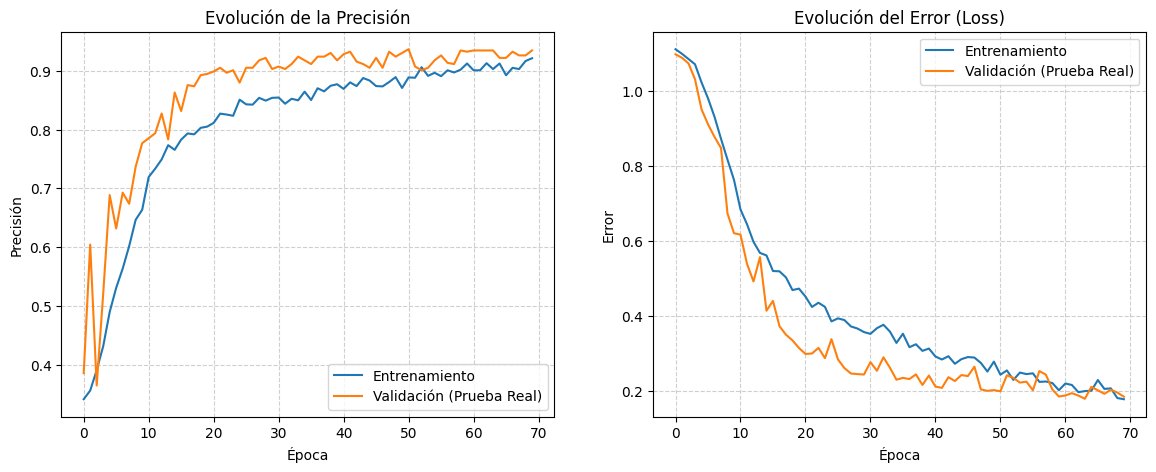

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      musica       0.93      0.90      0.92       158
     trafico       0.94      0.96      0.95       158
      neutro       0.93      0.95      0.94       159

    accuracy                           0.93       475
   macro avg       0.93      0.93      0.93       475
weighted avg       0.93      0.93      0.93       475



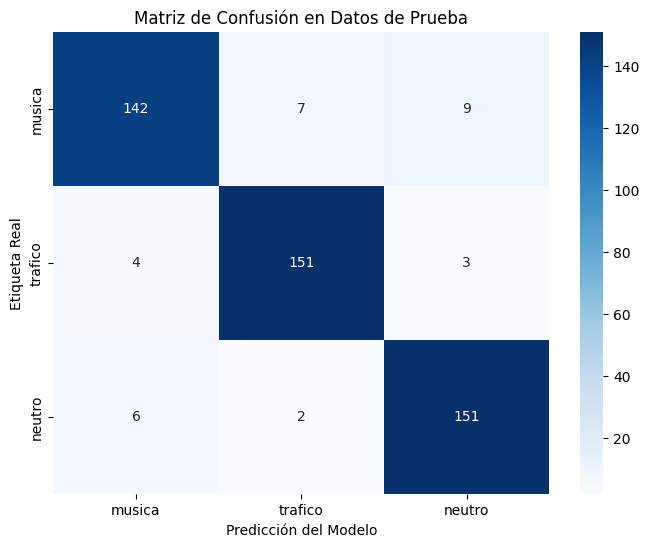


✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. CONFIGURACIÓN INICIAL (CORREGIDA)
# ==========================================
N_MELS = 26   # 🚀 CORRECCIÓN 1: Nomenclatura correcta (Log-Mel, no MFCC)
N_FRAMES = 301
DATAPOINTS_PER_FILE = N_MELS * N_FRAMES
BASE_PATH = "./dataset"
CLASSES = ["musica", "trafico", "neutro"]

X_all, y_all = [], []

print("Cargando el dataset limpio y formateando la memoria...")

# ==========================================
# 2. CARGA DE DATOS Y CORRECCIÓN DE MEMORIA
# ==========================================
for class_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(BASE_PATH, class_name, "mel")
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".bin"):
                file_path = os.path.join(folder_path, file)
                data = np.fromfile(file_path, dtype=np.float32)
                
                if len(data) == DATAPOINTS_PER_FILE:
                    
                    # 🚨 LECTURA DE MEMORIA C++ vs PYTHON CORREGIDA 🚨
                    # PASO A: Leer exactamente como el array de C++ (float mel[N_MELS][N_FRAMES])
                    data_correcta = data.reshape(N_MELS, N_FRAMES)
                    
                    # PASO B: Transponer (girar) la matriz para intercambiar los ejes. 
                    data_transpuesta = data_correcta.T
                    
                    # PASO C: Añadir la dimensión de "canal de color" (1) que exige la CNN
                    data_2d = np.expand_dims(data_transpuesta, axis=-1)
                    
                    X_all.append(data_2d)
                    y_all.append(class_idx)

X_all = np.array(X_all)
y_all = np.array(y_all)

# ==========================================
# 3. BALANCEO DE CLASES (Undersampling)
# ==========================================
conteo = np.bincount(y_all)
min_muestras = np.min(conteo)
print(f"\nBalanceando a {min_muestras} muestras por clase para evitar sesgos...")

indices_balanceados = []
for i in range(len(CLASSES)):
    idx_clase = np.where(y_all == i)[0]
    idx_seleccionados = np.random.choice(idx_clase, min_muestras, replace=False)
    indices_balanceados.extend(idx_seleccionados)

np.random.shuffle(indices_balanceados)
X_bal = X_all[indices_balanceados]
y_bal = y_all[indices_balanceados]

# ==========================================
# 4. DIVISIÓN TRAIN/TEST (80% / 20%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

# ==========================================
# 4.5 ESCALADO SUAVE (0.0 a 1.0)
# ==========================================
print("\nEscalando los datos al rango [0, 1] dividiendo por 15.0...")
# 🚀 CORRECCIÓN 2: Evita el colapso del gradiente (Loss = 5.0+) en la Época 1
X_train = X_train / 15.0
X_test = X_test / 15.0

print(f"Datos de Entrenamiento: {len(X_train)} | Datos de Prueba (Invisibles para la red): {len(X_test)}")

# ==========================================
# 5. ARQUITECTURA DEL MODELO (Con Dropout Ligero)
# ==========================================
print("\nConstruyendo la CNN con Dropout Quirúrgico...")
model = models.Sequential([
    layers.Input(shape=(N_FRAMES, N_MELS, 1)), 
    
    # Capas de extracción al 100% de capacidad
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Toma de decisiones
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    
    # 🚀 Aquí agregamos el Dropout Ligero (apagamos solo el 15% de las neuronas)
    layers.Dropout(0.20), 
    
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
print("\nIniciando entrenamiento formal (20 épocas)...")
##history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)
history = model.fit(X_train, y_train, epochs=70, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# ==========================================
# 7. EVALUACIÓN Y GRÁFICOS PARA EL REPORTE
# ==========================================
print("\nGenerando métricas y gráficos...")

# 7.1 Curvas de Aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación (Prueba Real)')
axes[0].set_title('Evolución de la Precisión')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Precisión')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history.history['loss'], label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación (Prueba Real)')
axes[1].set_title('Evolución del Error (Loss)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Error')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.show()

# 7.2 Matriz de Confusión
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matriz de Confusión en Datos de Prueba')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# ==========================================
# 8. GUARDAR EL MODELO
# ==========================================
model.save("modelo_clasificacion_audio.h5")
print("\n✅ Modelo guardado como 'modelo_clasificacion_audio.h5' - Listo para conversión a TFLite")

Cuantizar modelo a int8

In [26]:
import tensorflow as tf
import numpy as np

# 1. Configurar el convertidor para Full Integer Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Generador de datos representativos (cumpliendo: log-mel -> /15) 
def representative_data_gen():
    # Usamos X_train porque YA está escalado (/15) en el script anterior
    for input_value in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(100):
        yield [tf.cast(input_value, tf.float32)]

converter.representative_dataset = representative_data_gen

# Forzar salida y entrada a INT8 para el ESP32 [cite: 3]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

# Guardar binario
with open("modelo_audio_int8.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\angel\AppData\Local\Temp\tmpy93v6uuv\assets


INFO:tensorflow:Assets written to: C:\Users\angel\AppData\Local\Temp\tmpy93v6uuv\assets


Saved artifact at 'C:\Users\angel\AppData\Local\Temp\tmpy93v6uuv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 301, 26, 1), dtype=tf.float32, name='input_layer_11')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2269961073104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2269961060816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268626734352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268618962704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268618958864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268618955792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2269961073296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2269961071760: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [27]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Guarda estos valores, los necesitas para: q = round(val / scale) + zero_point 
input_scale = input_details[0]['quantization'][0]
input_zero_point = input_details[0]['quantization'][1]

print("🔎 DETALLES DE CUANTIZACIÓN PARA ESP32:")
print(f"INPUT - Tipo: {input_details[0]['dtype']}")
print(f"INPUT - Scale: {input_scale}")
print(f"INPUT - Zero Point: {input_zero_point}")
print("-" * 30)
print(f"OUTPUT - Tipo: {output_details[0]['dtype']}")

🔎 DETALLES DE CUANTIZACIÓN PARA ESP32:
INPUT - Tipo: <class 'numpy.int8'>
INPUT - Scale: 0.0036601307801902294
INPUT - Zero Point: -128
------------------------------
OUTPUT - Tipo: <class 'numpy.int8'>


C:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [28]:
# Tomar una muestra aleatoria de prueba
test_sample = X_test[0] # Ya está /15
label_real = y_test[0]

# 1. Cuantizar manualmente (Simulando lo que hará el ESP32) 
input_quantized = np.round(test_sample / input_scale) + input_zero_point
input_quantized = np.clip(input_quantized, -128, 127).astype(np.int8)

# 2. Ejecutar inferencia en el intérprete
interpreter.set_tensor(input_details[0]['index'], np.expand_dims(input_quantized, axis=0))
interpreter.invoke()

# 3. Obtener resultado
output_quantized = interpreter.get_tensor(output_details[0]['index'])
prediccion = np.argmax(output_quantized)

print(f"Clase Real: {CLASSES[label_real]}")
print(f"Predicción INT8: {CLASSES[prediccion]}")

Clase Real: neutro
Predicción INT8: neutro


Evaluar modelo int8

In [29]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Cargar modelo TFLite
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Parámetros de cuantización
in_scale, in_zero = input_details[0]['quantization']
out_scale, out_zero = output_details[0]['quantization']

print("Input scale:", in_scale)
print("Input zero:", in_zero)

Input scale: 0.0036601307801902294
Input zero: -128


In [32]:
def infer_int8(sample):
    # 🔴 AÑADIR DIMENSIÓN BATCH
    sample = np.expand_dims(sample, axis=0)

    # 🔴 CUANTIZACIÓN
    sample_q = np.round(sample / in_scale + in_zero).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], sample_q)
    interpreter.invoke()

    output_q = interpreter.get_tensor(output_details[0]['index'])

    # 🔴 DESCUANTIZACIÓN
    output_f = (output_q.astype(np.float32) - out_zero) * out_scale

    return output_f[0]  # quitar batch al salir

In [33]:
y_pred = []

print("Evaluando modelo INT8...")

for i in range(len(X_test)):
    output = infer_int8(X_test[i])
    pred_class = np.argmax(output)
    y_pred.append(pred_class)

y_pred = np.array(y_pred)

accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Accuracy INT8: {accuracy:.4f}")

Evaluando modelo INT8...

✅ Accuracy INT8: 0.9347


In [34]:
CLASSES = ["musica", "trafico", "neutro"]

print("\n--- REPORTE INT8 ---")
print(classification_report(y_test, y_pred, target_names=CLASSES))


--- REPORTE INT8 ---
              precision    recall  f1-score   support

      musica       0.93      0.90      0.92       158
     trafico       0.94      0.96      0.95       158
      neutro       0.93      0.95      0.94       159

    accuracy                           0.93       475
   macro avg       0.93      0.93      0.93       475
weighted avg       0.93      0.93      0.93       475



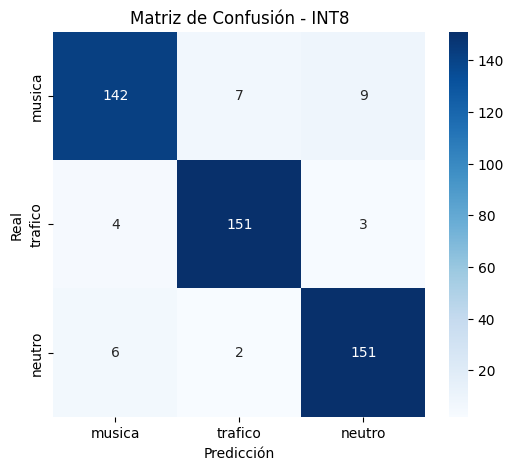

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES,
            yticklabels=CLASSES)

plt.title("Matriz de Confusión - INT8")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Prueba de porcentajes malos en inferencia en el esp32, la vamos a hacer aca con lo que esta leyendo el esp32

In [2]:
import numpy as np
import tensorflow as tf

CLASSES = ["Musica", "Trafico", "Neutro"]

# 1. Cargar el modelo INT8
interpreter = tf.lite.Interpreter(model_path="modelo_tinyml_int8.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Cargar el DUMP crudo del ESP32
# Asegúrate de poner 26 y 301 en el orden en que la IA lo espera
esp32_input = np.loadtxt("esp32_dump.txt", dtype=np.int8)
esp32_input = esp32_input.reshape(1, 301, 26, 1) 

# 3. Inyectar y ejecutar
interpreter.set_tensor(input_details[0]['index'], esp32_input)
interpreter.invoke()

# 4. Resultados exactos
salida_int8 = interpreter.get_tensor(output_details[0]['index'])[0]
scale = output_details[0]['quantization'][0]
zero_point = output_details[0]['quantization'][1]

print("🔎 RESULTADOS DEL TENSOR DEL ESP32 EJECUTADO EN PYTHON:")
for i in range(3):
    prob = (float(salida_int8[i]) - float(zero_point)) * scale
    print(f"{CLASSES[i]}: {prob * 100:.1f}%")

🔎 RESULTADOS DEL TENSOR DEL ESP32 EJECUTADO EN PYTHON:
Musica: 60.5%
Trafico: 35.9%
Neutro: 3.5%


In [3]:
import numpy as np
import tensorflow as tf

CLASSES = ["Musica", "Trafico", "Neutro"]

# 1. Cargar el modelo INT8
interpreter = tf.lite.Interpreter(model_path="modelo_tinyml_int8.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Cargar el DUMP crudo del ESP32
# Asegúrate de poner 26 y 301 en el orden en que la IA lo espera
# 1. Leer los datos crudos
esp32_input = np.loadtxt("esp32_dump.txt", dtype=np.int8)

# 2. LA PRUEBA: Forzar la reconstrucción invertida (26, 301) 
# y luego transponerla (301, 26) para que el modelo la acepte sin dar error de forma
esp32_input = esp32_input.reshape(1, 26, 301, 1).transpose(0, 2, 1, 3)
# 3. Inyectar y ejecutar
interpreter.set_tensor(input_details[0]['index'], esp32_input)
interpreter.invoke()

# 4. Resultados exactos
salida_int8 = interpreter.get_tensor(output_details[0]['index'])[0]
scale = output_details[0]['quantization'][0]
zero_point = output_details[0]['quantization'][1]

print("🔎 RESULTADOS DEL TENSOR DEL ESP32 EJECUTADO EN PYTHON:")
for i in range(3):
    prob = (float(salida_int8[i]) - float(zero_point)) * scale
    print(f"{CLASSES[i]}: {prob * 100:.1f}%")

🔎 RESULTADOS DEL TENSOR DEL ESP32 EJECUTADO EN PYTHON:
Musica: 99.6%
Trafico: 0.0%
Neutro: 0.0%


In [4]:
print(input_details[0]['shape'])

[  1 301  26   1]


In [5]:
import numpy as np
import tensorflow as tf

CLASSES = ["Musica", "Trafico", "Neutro"]

# 1. Cargar el modelo INT8
print("Cargando modelo...")
interpreter = tf.lite.Interpreter(model_path="modelo_tinyml_int8.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Cargar el NUEVO DUMP crudo del ESP32
print("Cargando nueva matriz del ESP32...")
esp32_input = np.loadtxt("esp32_dump_2.txt", dtype=np.int8)

# 🔴 Inyectamos los datos en el orden natural y correcto (301, 26) SIN invertir nada
esp32_input = esp32_input.reshape(1, 301, 26, 1) 

# 3. Inyectar y ejecutar
interpreter.set_tensor(input_details[0]['index'], esp32_input)
interpreter.invoke()

# 4. Resultados exactos
salida_int8 = interpreter.get_tensor(output_details[0]['index'])[0]
scale = output_details[0]['quantization'][0]
zero_point = output_details[0]['quantization'][1]

print("\n🔎 RESULTADOS REALES DEL ESP32 EJECUTADOS EN PYTHON:")
for i in range(3):
    # 🔴 EVITAMOS EL OVERFLOW: Convertimos a float antes de restar
    prob = (float(salida_int8[i]) - float(zero_point)) * scale
    print(f"{CLASSES[i]}: {prob * 100:.1f}%")

Cargando modelo...
Cargando nueva matriz del ESP32...

🔎 RESULTADOS REALES DEL ESP32 EJECUTADOS EN PYTHON:
Musica: 0.0%
Trafico: 0.0%
Neutro: 99.6%


In [3]:
model.summary()


NameError: name 'model' is not defined